# Granite based on local behavior (effects) for Kin8nm


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import KFold, RandomizedSearchCV, train_test_split
from sklearn.metrics import root_mean_squared_error
from joblib import dump, load

# Local imports
from granite.data import get_data_kin8nm
from granite.decompositions import get_components_brute_force, get_regional_decompositions

/home/gabriel/anaconda3/envs/GRANITE/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Input Features

The BikeSharing dataset aims to predict the hourly count of bike rentals between years 2011
and 2012 in Washington state, based on time and weather features. It involves 17K instances
and 10 features.

First load the data and a `Features` object that stores information about the various features. 
Note that the data **X** must **always** be a numerical numpy array. Categorical features are assumed 
to have been ordinally encoded.

In [2]:
# Built-in function for the BikeSharing dataset
X, y, features = get_data_kin8nm()
print(X.shape)
features.summary()

(8192, 8)
|Idx|        Name        |        Type        |    Card    |      Groups      |
-------------------------------------------------------------------------------
| 0 | theta1             | num                | inf        | [0]              |
| 1 | theta2             | num                | inf        | [1]              |
| 2 | theta3             | num                | inf        | [2]              |
| 3 | theta4             | num                | inf        | [3]              |
| 4 | theta5             | num                | inf        | [4]              |
| 5 | theta6             | num                | inf        | [5]              |
| 6 | theta7             | num                | inf        | [6]              |
| 7 | theta8             | num                | inf        | [7]              |
-------------------------------------------------------------------------------



In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = MLPRegressor(random_state=42, max_iter=500)


**Do not run the following cells if you have already trained the model. Skip to later cells.**

In [ ]:
# For MLP
grid = {"hidden_layer_sizes": [(10, 5), (20, 10), (30, 15)],
        "learning_rate_init": np.logspace(-4, -1, 10),
        "alpha": np.logspace(-4, -1, 10),
        "momentum": [0.75, 0.9, 0.99, 0.999]
}

search = RandomizedSearchCV(
    model,
    cv=KFold(),
    scoring='neg_root_mean_squared_error',
    param_distributions=grid,
    verbose=2,
    n_iter=20,
    random_state=42
)
search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END alpha=0.1, hidden_layer_sizes=(30, 15), learning_rate_init=0.002154434690031882, momentum=0.99; total time=   0.9s
[CV] END alpha=0.1, hidden_layer_sizes=(30, 15), learning_rate_init=0.002154434690031882, momentum=0.99; total time=   0.7s
[CV] END alpha=0.1, hidden_layer_sizes=(30, 15), learning_rate_init=0.002154434690031882, momentum=0.99; total time=   0.7s
[CV] END alpha=0.1, hidden_layer_sizes=(30, 15), learning_rate_init=0.002154434690031882, momentum=0.99; total time=   0.6s
[CV] END alpha=0.1, hidden_layer_sizes=(30, 15), learning_rate_init=0.002154434690031882, momentum=0.99; total time=   0.7s
[CV] END alpha=0.021544346900318822, hidden_layer_sizes=(10, 5), learning_rate_init=0.01, momentum=0.9; total time=   0.4s
[CV] END alpha=0.021544346900318822, hidden_layer_sizes=(10, 5), learning_rate_init=0.01, momentum=0.9; total time=   0.5s
[CV] END alpha=0.021544346900318822, hidden_layer_sizes=(10, 5), learnin

,estimator,MLPRegressor(...ndom_state=42)
,param_distributions,"{'alpha': array([0.0001..., 0.1 ]), 'hidden_layer_sizes': [(10, ...), (20, ...), ...], 'learning_rate_init': array([0.0001..., 0.1 ]), 'momentum': [0.75, 0.9, ...]}"
,n_iter,20
,scoring,'neg_root_mean_squared_error'
,n_jobs,None
,refit,True
,cv,KFold(n_split...shuffle=False)
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [8]:
# Recover the optimal CV model
model = search.best_estimator_
res = search.cv_results_
cv_perf = np.nan_to_num(-res['mean_test_score'], nan=1e10)
best_idx = np.argmin(cv_perf)

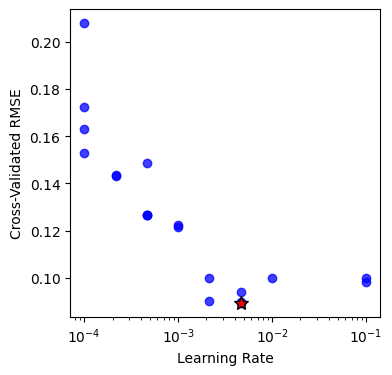

In [10]:
plt.figure(figsize=(4, 4))
plt.scatter(res['param_learning_rate_init'], cv_perf, c='b', alpha=0.75)
plt.plot(res['param_learning_rate_init'][best_idx], cv_perf[best_idx], 'r*', markersize=10, markeredgecolor='k')
plt.xlabel("Learning Rate")
plt.ylabel("Cross-Validated RMSE")
plt.xscale('log')
plt.show()

In [11]:
# Pickle the model
dump(model, os.path.join("models", "kin8nm_mlp.joblib"))

['models/kin8nm_mlp.joblib']

**Start from here if you have already trained and dumped the model.**

In [63]:
from sklearn.metrics import mean_squared_error
# Load the model
model = load(os.path.join("models", "kin8nm_mlp.joblib"))
test_preds = model.predict(X_test)
print(f" R2 of the model : {1 - mean_squared_error(test_preds, y_test) / y_test.var():.2f}")

 R2 of the model : 0.90


## Disagreement due to interactions: Marginal Pure-Full Effects (individual feature influence)

We can understand how an individual features impact the model response by computing their pure and full marginal effects.
We first compute the Anchored decomposition.

In [17]:
from granite.decompositions import get_components_brute_force
# Compute the H^k matrices using a subset of 1000 training points
background = X_test[:1000]
decomposition = get_components_brute_force(model.predict, background, background, features=features, anchored=True, interactions=2, show_bar=True)

Functional Decomposition: 0it [00:00, ?it/s]

Functional Decomposition: 8it [00:03,  2.61it/s]
Functional Decomposition: 28it [00:12,  2.21it/s]


In [17]:
# The keys are tuples encoding subsets of features
display(decomposition.keys())
# The () key is the intercept
display(decomposition[()].shape)
# The key (i,) is the main effect of feature i in the Anchored Decomposition
display(decomposition[(0,)].shape)

dict_keys([(), (0,), (1,), (2,), (3,), (4,), (5,), (6,), (7,), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7), (2, 3), (2, 4), (2, 5), (2, 6), (2, 7), (3, 4), (3, 5), (3, 6), (3, 7), (4, 5), (4, 6), (4, 7), (5, 6), (5, 7), (6, 7)])

(1000,)

(1000, 1000)

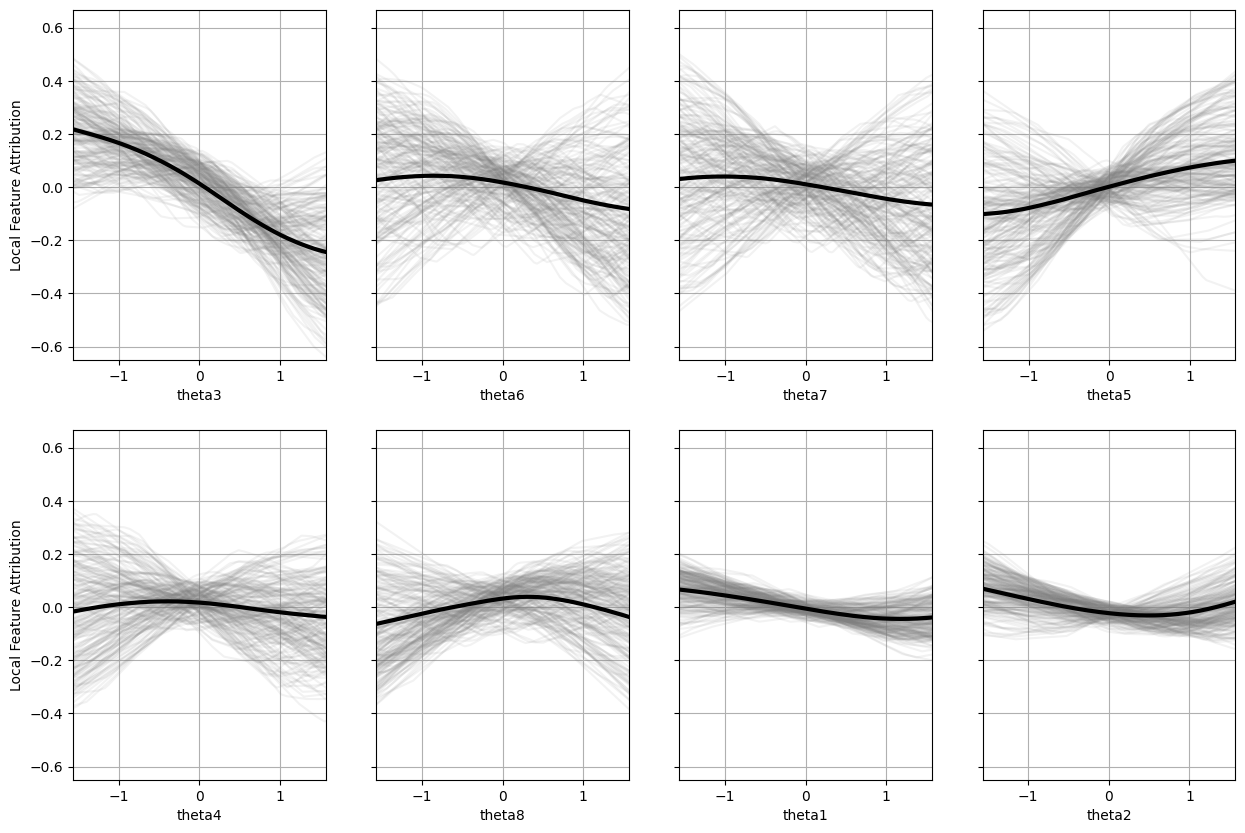

In [20]:
from granite.plots import partial_dependence_plot

# Plot the PDP and the ICE curves
partial_dependence_plot(decomposition, background, features, centered=True, figsize=(15, 10), n_cols = 4)
plt.savefig("../figures/kin8nm_pure_full_global_all.pdf", bbox_inches="tight")

plt.show()

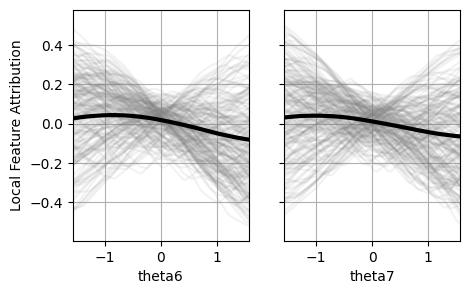

In [21]:
partial_dependence_plot(decomposition, background, features, idxs = [5, 6], centered=True, figsize=(5, 3))
plt.savefig("../figures/kin8nm_pure_full_global_main.pdf", bbox_inches='tight', dpi=300)
plt.show()

In [22]:
from granite.fd_trees import FDTree
from granite.experiments import get_marginal_pure_vs_full_loss_fn

# Option 1: We minimize all interactions
U = [(i,) for i in range(len(features))]
features_to_split_upon = [i for i in range(len(features))]

# We penalize all pure-vs-full effects of each feature, which ammounts to minimizing all interactions within the model
loss_fn = get_marginal_pure_vs_full_loss_fn(
    decomposition=decomposition,
    U=U
)
tree = FDTree(max_depth=3, features=features.select(features_to_split_upon), alpha=0.01, save_losses=True)
tree.fit(background[:, features_to_split_upon], loss_fn=loss_fn)
tree.print(verbose=True)

Loss 1.0000
Samples 1000
If theta7 ≤ 0.0512:
|   Loss 0.4214
|   Samples 525
|   If theta6 ≤ -0.1573:
|   |   Loss 0.1135
|   |   Samples 223
|   |   If theta5 ≤ -0.1204:
|   |   |   Loss 0.0365
|   |   |   Samples 100
|   |   |   Region 0
|   |   else:
|   |   |   Loss 0.0421
|   |   |   Samples 123
|   |   |   Region 1
|   else:
|   |   Loss 0.1831
|   |   Samples 302
|   |   If theta4 ≤ -0.2973:
|   |   |   Loss 0.0552
|   |   |   Samples 113
|   |   |   Region 2
|   |   else:
|   |   |   Loss 0.0848
|   |   |   Samples 189
|   |   |   Region 3
else:
|   Loss 0.3845
|   Samples 475
|   If theta6 ≤ 0.1660:
|   |   Loss 0.1694
|   |   Samples 261
|   |   If theta5 ≤ -0.3186:
|   |   |   Loss 0.0567
|   |   |   Samples 98
|   |   |   Region 4
|   |   else:
|   |   |   Loss 0.0723
|   |   |   Samples 163
|   |   |   Region 5
|   else:
|   |   Loss 0.1193
|   |   Samples 214
|   |   If theta5 ≤ -0.0403:
|   |   |   Loss 0.0361
|   |   |   Samples 96
|   |   |   Region 6
|   |   else:
|  

In [23]:
# Using regional backgrounds
larger_background = X_test
regions = tree.predict(larger_background[:, features_to_split_upon])
print(np.unique(regions, return_counts=True))
rules = tree.rules()
print(rules)

(array([0, 1, 2, 3, 4, 5, 6, 7], dtype=int32), array([165, 221, 177, 293, 161, 262, 157, 203]))
{0: '(theta7<=0.05 & theta6<=-0.16 & theta5<=-0.12)', 1: '(theta7<=0.05 & theta6<=-0.16 & theta5>-0.12)', 2: '(theta7<=0.05 & theta6>-0.16 & theta4<=-0.30)', 3: '(theta7<=0.05 & theta6>-0.16 & theta4>-0.30)', 4: '(theta7>0.05 & theta6<=0.17 & theta5<=-0.32)', 5: '(theta7>0.05 & theta6<=0.17 & theta5>-0.32)', 6: '(theta7>0.05 & theta6>0.17 & theta5<=-0.04)', 7: '(theta7>0.05 & theta6>0.17 & theta5>-0.04)'}


In [25]:
# We compute regional decompositions
regional_backgrounds = [[]] * tree.n_regions
regional_decomposition = [[]] * tree.n_regions
regional_shap = [[]] * tree.n_regions
for r in range(tree.n_regions):
    regional_backgrounds[r] = larger_background[regions==r]
    # Regional Decomposition
    regional_decomposition[r] = get_components_brute_force(
                                                    model.predict,
                                                    regional_backgrounds[r],
                                                    regional_backgrounds[r],
                                                    features,
                                                    anchored=True
                                                )

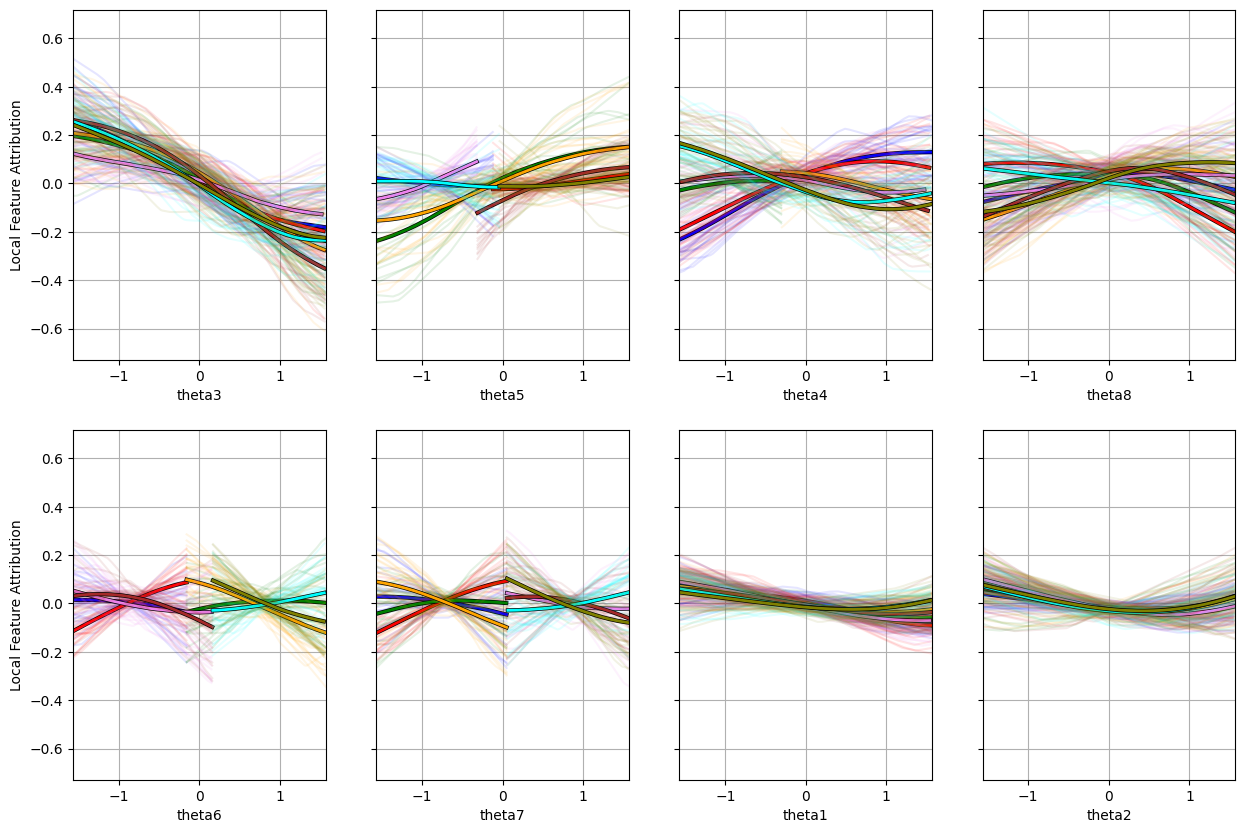

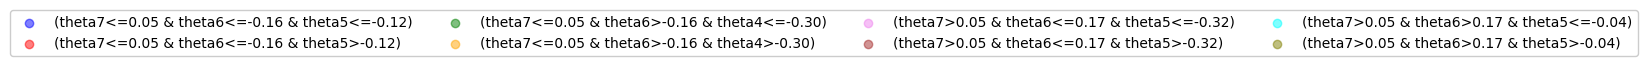

In [26]:
from granite.plots import plot_legend

# Regional h_i and SHAP values
partial_dependence_plot(regional_decomposition, regional_backgrounds, features, centered=True, figsize=(15, 10), n_cols = 4)
plt.savefig("../figures/kin8nm_pure_full_regional_all.pdf", bbox_inches='tight')

plot_legend(rules, ncol=4)
plt.savefig("../figures/kin8nm_pure_full_regional_all_legend.pdf", bbox_inches='tight')

plt.show()

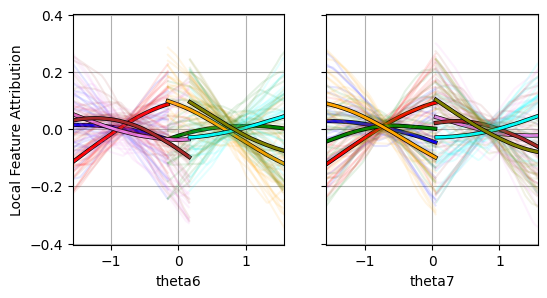

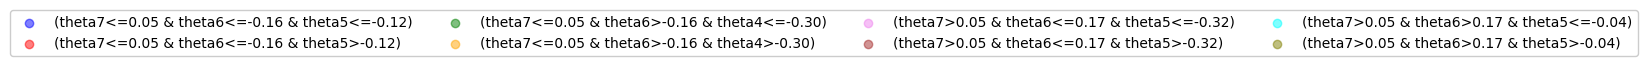

In [27]:
from granite.plots import plot_legend

# Regional h_i and SHAP values
partial_dependence_plot(regional_decomposition, regional_backgrounds, features, idxs = [5, 6], centered=True, figsize=(6, 3), n_cols = 2)
plt.savefig("../figures/kin8nm_pure_full_regional_main.pdf", bbox_inches='tight')

plot_legend(rules, ncol=4)
plt.savefig("../figures/kin8nm_pure_full_regional_main_legend.pdf", bbox_inches='tight')

plt.show()

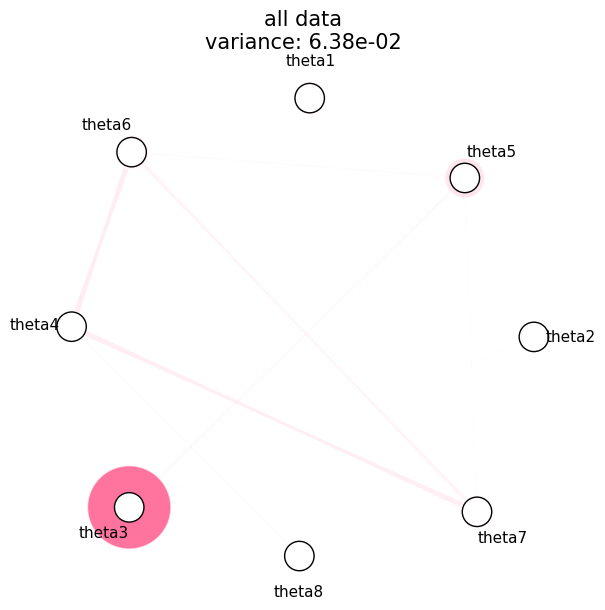

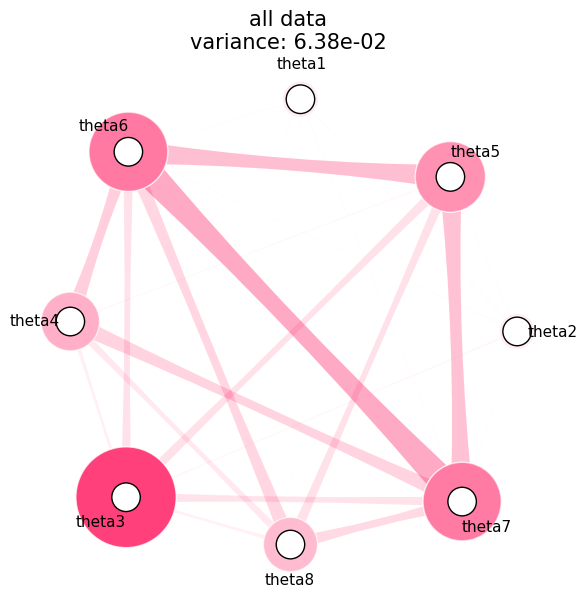

In [ ]:
# I just copy paste from shapiq and hope for the best

import networkx as nx
import numpy as np
from matplotlib import pyplot as plt

from shapiq.plot._config import get_color
from shapiq.plot.si_graph import _normalize_value, _draw_explanation_nodes, _draw_fancy_hyper_edges, _draw_graph_edges, _draw_graph_nodes

NORMAL_NODE_SIZE = 0.125  # 0.125
BASE_ALPHA_VALUE = 1.0  # the transparency level for the highest interaction
BASE_SIZE = 0.40  # the size of the highest interaction edge (with scale factor 1)
ADJUST_NODE_ALPHA = True
LABEL_OFFSET = 0.03


def _draw_graph_labels(
    ax: plt.axis,
    pos: dict,
    graph: nx.Graph,
    *,
    nodes: list | None = None,
    normal_node_size: float = 1.0,
    plot_white_nodes: bool = False,
) -> None:
    """Adds labels to the nodes of the graph.

    Args:
        ax: The axis to draw the labels on.

        pos: The positions of the nodes.

        graph: The graph to draw the labels on.

        nodes: The nodes to draw the labels on. If ``None`` (default), all nodes are drawn.

        normal_node_size: The size of the nodes. Defaults to ``1.0``.

        plot_white_nodes: If set to ``True``, the nodes are drawn as white circles with the label
            inside. If set to ``False``, the labels are drawn next to the nodes. Defaults to
            ``False``.

    """
    for node in graph.nodes:
        if nodes is not None and node not in nodes:
            continue
        label = graph.nodes.get(node)["label"]
        position = pos[node]
        if plot_white_nodes:
            offset = (0, 0)
        else:
            # offset so the text is next to the node
            offset_norm = np.sqrt(position[0] ** 2 + position[1] ** 2)
            offset = (
                (LABEL_OFFSET + normal_node_size) * position[0] / offset_norm,
                (LABEL_OFFSET + normal_node_size) * position[1] / offset_norm,
            )
        ax.text(
            position[0] + offset[0],
            position[1] + offset[1],
            label,
            fontsize=plt.rcParams["font.size"] + 1,
            ha="center",
            va="center",
            color="black",
        )

def plot_pure_full_pairwise_strength(interaction_dict, feature_names, max_interaction):
    original_graph = nx.Graph()
    graph_nodes = list(range(len(features))) 
    for node in graph_nodes:
        node_label = feature_names[node]
        original_graph.add_node(node, label=node_label)


    # create explanation graph
    explanation_graph, explanation_nodes, explanation_edges = nx.Graph(), [], []
    for interaction, interaction_value in interaction_dict.items():
        interaction_size = len(interaction)
        interaction_strength = abs(interaction_value)

        attributes = {
            "color": get_color(interaction_value),
            "alpha": _normalize_value(interaction_value, max_interaction, BASE_ALPHA_VALUE),
            "interaction": interaction,
            "weight": interaction_strength * 1e10,
            "size": _normalize_value(interaction_value, max_interaction, BASE_SIZE),
        }

        # add main effect explanations as nodes
        if interaction_size == 1:
            player = interaction[0]
            explanation_graph.add_node(player, **attributes)
            explanation_nodes.append(player)

        # add 2-way interaction explanations as edges
        if interaction_size >= 2:
            explanation_edges.append(interaction)
            player_last = interaction[-1]
            if interaction_size > 2:
                dummy_node = tuple(interaction)
                explanation_graph.add_node(dummy_node, **attributes)
                player_last = dummy_node
            # add the edges between the players
            for player in interaction[:-1]:
                explanation_graph.add_edge(player, player_last, **attributes)

    pos = nx.spring_layout(original_graph, seed=42, k=None)
    pos = nx.kamada_kawai_layout(original_graph, scale=1.0, pos=pos)

    # # adjust pos such that the nodes are at least NORMAL_NODE_SIZE apart
    # if adjust_node_pos:
    #     pos = _adjust_position(pos, original_graph)

    # create the plot
    fig, ax = plt.subplots(figsize=(7, 7))
    # position now again the hyper-edges onto the normal nodes weight param is weight
    pos_explain = nx.spring_layout(
        explanation_graph, weight="weight", seed=42, pos=pos, fixed=graph_nodes
    )
    pos.update(pos_explain)
    _draw_fancy_hyper_edges(ax, pos, explanation_graph, hyper_edges=explanation_edges)
    _draw_explanation_nodes(
        ax,
        pos,
        explanation_graph,
        nodes=explanation_nodes,
        normal_node_size=NORMAL_NODE_SIZE,
    )

    # add the original graph structure on top
    _draw_graph_nodes(ax, pos, original_graph, normal_node_size=NORMAL_NODE_SIZE)
    _draw_graph_edges(ax, pos, original_graph, normal_node_size=NORMAL_NODE_SIZE)
    _draw_graph_labels(
            ax,
            pos,
            original_graph,
            normal_node_size=NORMAL_NODE_SIZE,
            plot_white_nodes=False,
        )

    # tidy up the plot
    ax.set_aspect("equal", adjustable="datalim")  # make y- and x-axis scales equal
    ax.axis("off")  # remove axis
    return fig, ax

pure_effects = {key: np.mean(H.mean(1)**2) for key, H in decomposition.items() if len(key) >= 1}
full_effects = {key: np.mean(H.mean(0)**2) for key, H in decomposition.items() if len(key) >= 1}
fig, ax = plot_pure_full_pairwise_strength(pure_effects, features.names(), max_interaction=0.04)
ax.set_title(f"all data\nvariance: {decomposition[()].var():.2e}", fontsize=15)
fig.savefig(os.path.join("..", "figures", "kin8nm_pure_interactions_var.pdf"))
fig, ax = plot_pure_full_pairwise_strength(full_effects, features.names(), max_interaction=0.04)
ax.set_title(f"all data\nvariance: {decomposition[()].var():.2e}", fontsize=15)
fig.savefig(os.path.join("..", "figures", "kin8nm_full_interactions_var.pdf"))

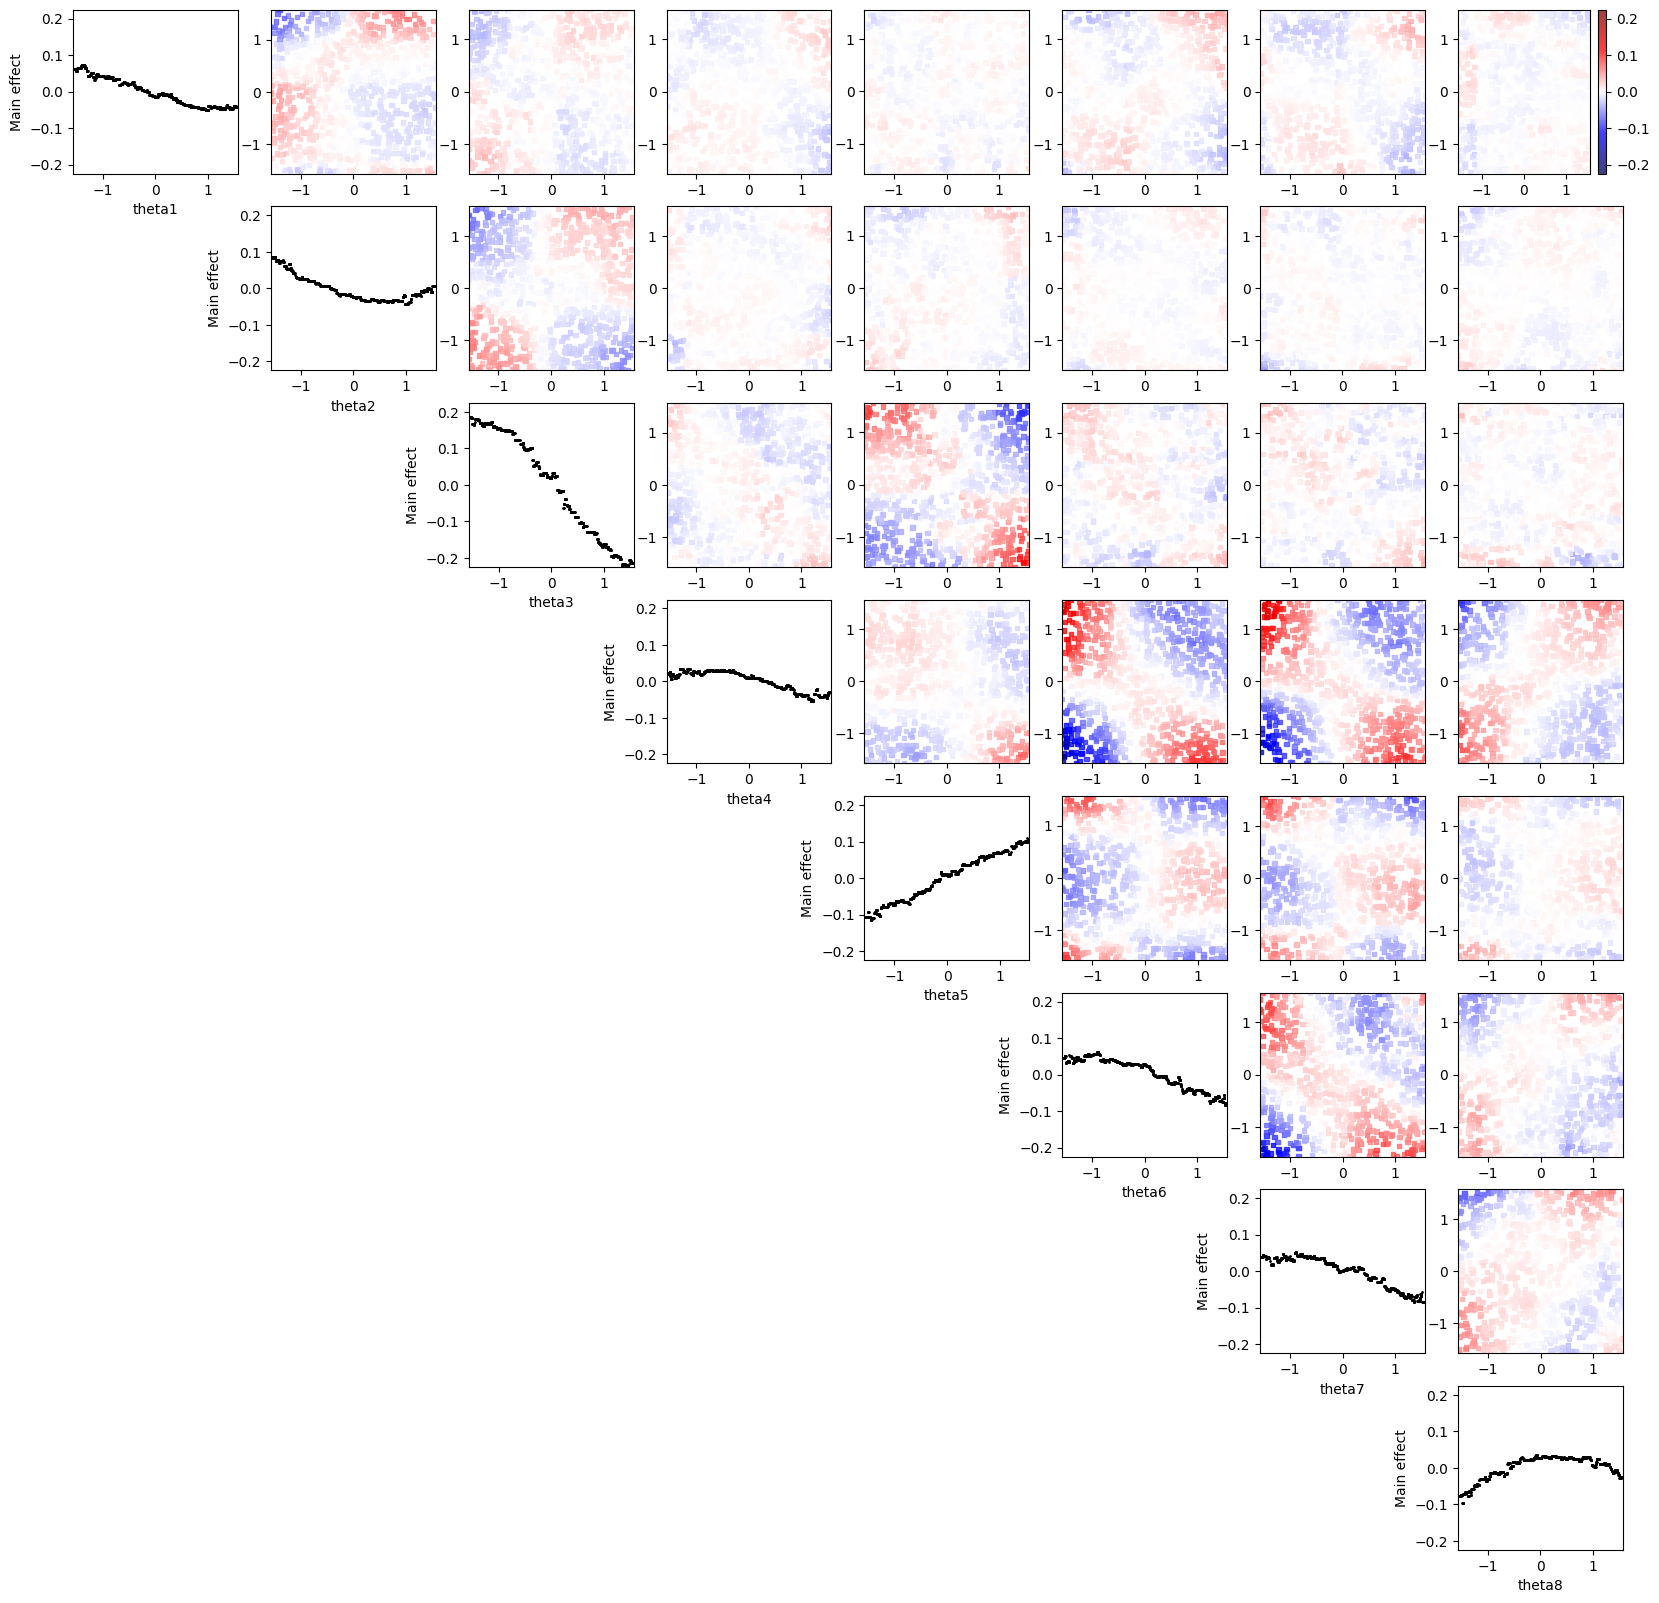

In [71]:
from typing import Union, List, Dict, Tuple
from matplotlib.colors import CenteredNorm

Decomposition = Dict[Tuple[int, ...], np.ndarray]

def plot_main_effect_and_interactions(decomposition: Union[Decomposition, List[Decomposition]], background: Union[np.ndarray, List[np.ndarray]], features):
    if isinstance(decomposition, dict):
        decompositions = [decomposition]
        backgrounds = [background]
        n_regions = 1
    else:
        n_regions = len(decomposition)
    
    # Parameters shared across figures
    max_abs_val = max([
                    max([
                        np.max(
                            np.abs(decomposition[key].mean(1))
                        ) for key in decomposition.keys() if len(key)> 0
                    ]) for decomposition in decompositions]
                )
    min_feature_value = np.zeros(len(features))
    max_feature_value = np.zeros(len(features))
    for i in range(len(features)):
        min_feature_value[i] = np.min([background[:, i].min() for background in backgrounds])
        max_feature_value[i] = np.min([background[:, i].max() for background in backgrounds])

    for r in range(n_regions):
        decomposition = decompositions[r]
        background = backgrounds[r]
        fig, axes = plt.subplots(len(features), len(features), figsize=(20, 20))
        # We plot the pure (0, 1) interaction from `region 1`
        for feature_1 in range(len(features)):
            for feature_2 in range(len(features)):
                curr_ax = axes[feature_1][feature_2]
                if feature_1 > feature_2:
                    curr_ax.remove()
                elif feature_1 == feature_2:
                    main_effect = decomposition[(feature_1,)].mean(1)
                    curr_ax.scatter(background[:, feature_1], main_effect, c='k', s=1)
                    curr_ax.set_xlabel(features.names()[feature_1])
                    curr_ax.set_ylabel('Main effect')
                    curr_ax.set_xlim(min_feature_value[feature_1], max_feature_value[feature_1])
                    curr_ax.set_ylim(-max_abs_val, max_abs_val)
                else:
                    interactions = decomposition[(feature_1, feature_2)].mean(1),
                    cbar = curr_ax.scatter(background[:, feature_1], background[:, feature_2], c=interactions, s=10, marker="s",
                                                cmap='seismic', alpha=0.75, norm=CenteredNorm(0, halfrange=max_abs_val))
                    curr_ax.set_xlim(min_feature_value[feature_1], max_feature_value[feature_1])
                    curr_ax.set_ylim(min_feature_value[feature_2], max_feature_value[feature_2])
        fig.colorbar(cbar, ax=axes[0, len(features)-1])


plot_main_effect_and_interactions(decomposition, background, features)
plt.savefig(os.path.join("..", "figures", "kin8nm_pure_pairwise_local.pdf"))

In [30]:
from granite.fd_trees import FDTree
from granite.experiments import get_marginal_pure_vs_full_loss_fn

# We minimize the pure-full interactions involving features x0 and x1
loss_fn = get_marginal_pure_vs_full_loss_fn(
    decomposition=decomposition,
    U=[(3, 5), (4, 5), (3, 6), (4, 6), (5, 6)]
)
tree = FDTree(features, max_depth=2, save_losses=True, branching_per_node=1, alpha=0.1)
tree.fit(background, loss_fn=loss_fn)
tree.print(verbose=True)

Loss 1.0000
Samples 1000
If theta6 ≤ 0.1553:
|   Loss 0.2331
|   Samples 550
|   If theta7 ≤ 0.5903:
|   |   Loss 0.0848
|   |   Samples 385
|   |   Region 0
|   else:
|   |   Loss 0.0327
|   |   Samples 165
|   |   Region 1
else:
|   Loss 0.2141
|   Samples 450
|   If theta7 ≤ 0.0025:
|   |   Loss 0.0493
|   |   Samples 225
|   |   Region 2
|   else:
|   |   Loss 0.0408
|   |   Samples 225
|   |   Region 3
Final Loss 0.2076


In [31]:
# Using regional backgrounds
regions = tree.predict(background)
display(regions[:10])
n_regions = tree.n_regions
rules = tree.rules()
display(rules)
_, count = np.unique(regions, return_counts=True)
display(count)

array([0, 2, 0, 3, 2, 1, 0, 2, 0, 1], dtype=int32)

{0: '(theta6<=0.16 & theta7<=0.59)',
 1: '(theta6<=0.16 & theta7>0.59)',
 2: '(theta6>0.16 & theta7<=0.00)',
 3: '(theta6>0.16 & theta7>0.00)'}

array([385, 165, 225, 225])

In [32]:
# We compute regional decompositions
regional_decomposition = [[]] * tree.n_regions
for r in range(tree.n_regions):
    regional_backgrounds[r] = background[regions==r]
regional_decomposition = get_regional_decompositions(decomposition, regions, regions, tree.n_regions)

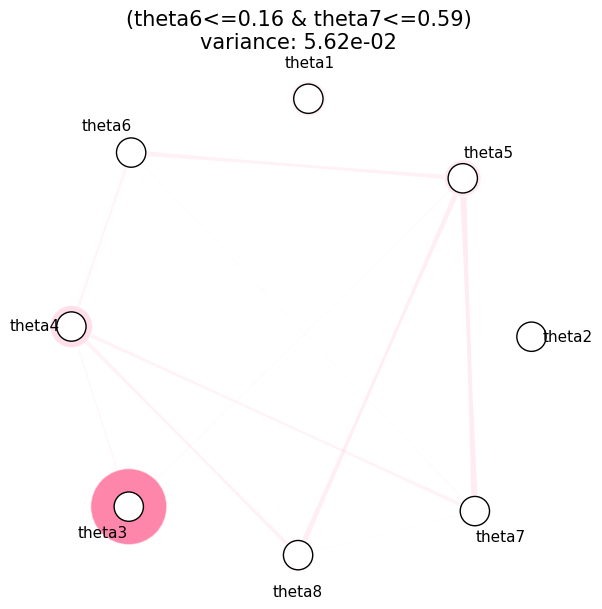

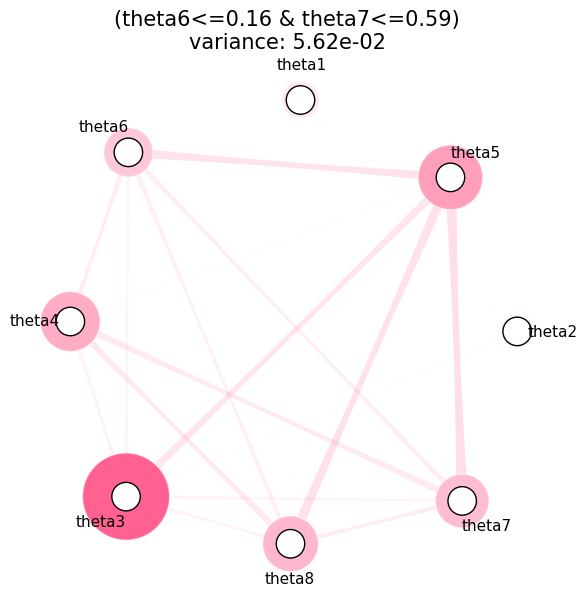

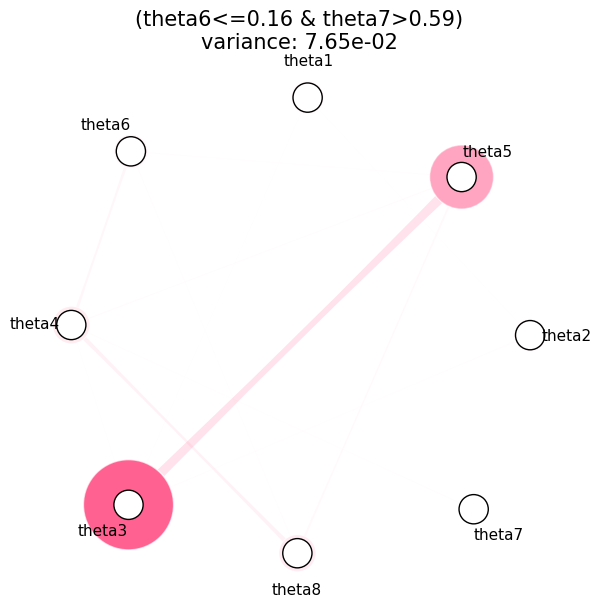

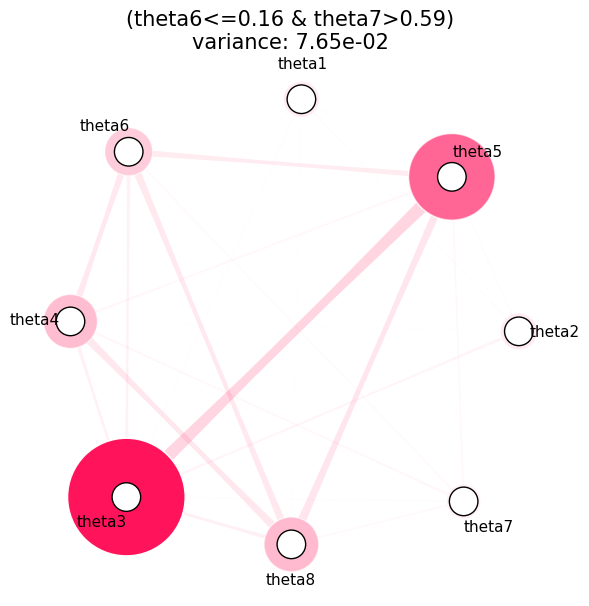

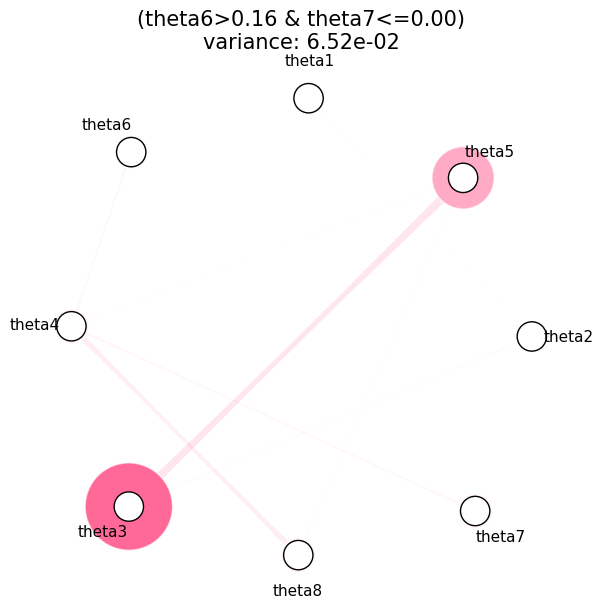

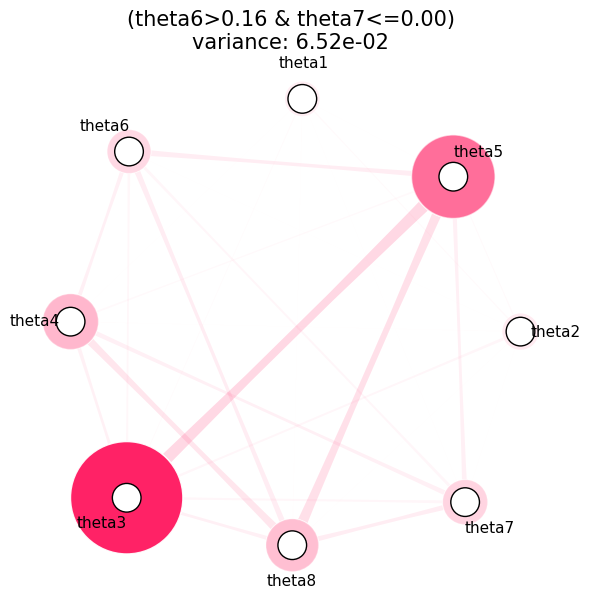

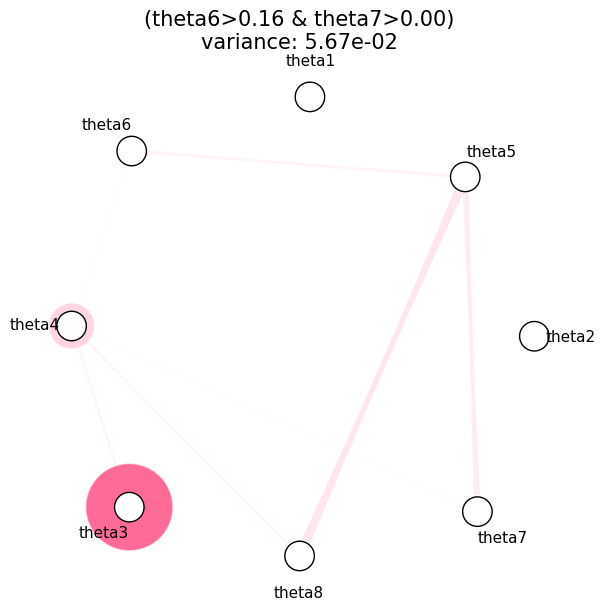

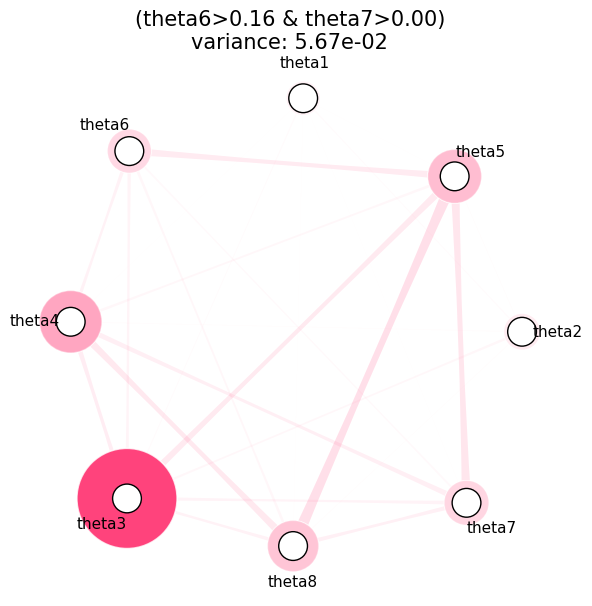

In [50]:
for r in range(n_regions):
    pure_effects = {key: np.mean(H.mean(1)**2) for key, H in regional_decomposition[r].items() if len(key) >= 1}
    full_effects = {key: np.mean(H.mean(0)**2) for key, H in regional_decomposition[r].items() if len(key) >= 1}
    # print(max(pure_effects.values()))
    # print(max(full_effects.values()))
    fig, ax = plot_pure_full_pairwise_strength(pure_effects, features.names(), max_interaction=0.04)
    ax.set_title(f"{rules[r]}\nvariance: {regional_decomposition[r][()].var():.2e}", fontsize=15)
    fig.savefig(os.path.join("..", "figures", f"kin8nm_pure_interactions_var_region_{r}.pdf"))
    fig, ax = plot_pure_full_pairwise_strength(full_effects, features.names(), max_interaction=0.04)
    ax.set_title(f"{rules[r]}\nvariance: {regional_decomposition[r][()].var():.2e}", fontsize=15)
    fig.savefig(os.path.join("..", "figures", f"kin8nm_full_interactions_var_region_{r}.pdf"))

In [ ]:
def plot_main_effect_and_interactions(decompositions: Union[Decomposition, List[Decomposition]], backgrounds: Union[np.ndarray, List[np.ndarray]], features):
    if isinstance(decompositions, dict):
        decompositions = [decompositions]
        backgrounds = [backgrounds]
        n_regions = 1
    else:
        n_regions = len(decompositions)
    
    # Parameters shared across figures
    max_abs_val = max([
                    max([
                        np.max(
                            np.abs(decomposition[key].mean(1))
                        ) for key in decomposition.keys() if len(key)> 0
                    ]) for decomposition in decompositions]
                )
    min_feature_value = np.zeros(len(features))
    max_feature_value = np.zeros(len(features))
    for i in range(len(features)):
        min_feature_value[i] = np.min([background[:, i].min() for background in backgrounds])
        max_feature_value[i] = np.max([background[:, i].max() for background in backgrounds])

    for r in range(n_regions):
        decomposition = decompositions[r]
        background = backgrounds[r]
        fig, axes = plt.subplots(len(features), len(features), figsize=(20, 20))
        # We plot the pure (0, 1) interaction from `region 1`
        for feature_1 in range(len(features)):
            for feature_2 in range(len(features)):
                curr_ax = axes[feature_1][feature_2]
                if feature_1 > feature_2:
                    curr_ax.remove()
                elif feature_1 == feature_2:
                    main_effect = decomposition[(feature_1,)].mean(1)
                    curr_ax.scatter(background[:, feature_1], main_effect, c='k', s=1)
                    curr_ax.set_xlabel(features.names()[feature_1])
                    curr_ax.set_ylabel('Main effect')
                    curr_ax.set_xlim(min_feature_value[feature_1], max_feature_value[feature_1])
                    curr_ax.set_ylim(-max_abs_val, max_abs_val)
                else:
                    interactions = decomposition[(feature_1, feature_2)].mean(1),
                    cbar = curr_ax.scatter(background[:, feature_2], background[:, feature_1], c=interactions, s=10, marker="s",
                                                cmap='seismic', alpha=0.75, norm=CenteredNorm(0, halfrange=max_abs_val))
                    curr_ax.set_xlim(min_feature_value[feature_2], max_feature_value[feature_2])
                    curr_ax.set_ylim(min_feature_value[feature_1], max_feature_value[feature_1])
        fig.colorbar(cbar, ax=axes[0, len(features)-1])
        plt.savefig(os.path.join("..", "figures", f"kin8nm_pure_pairwise_local_region{r}.pdf"))

plot_main_effect_and_interactions(regional_decomposition, regional_backgrounds, features)

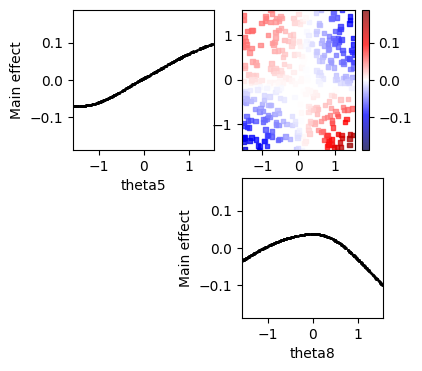

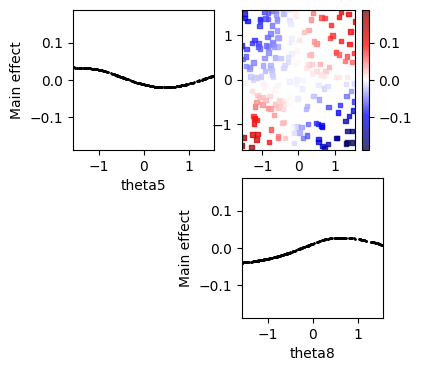

In [62]:
from typing import Union, List, Dict, Tuple
from matplotlib.colors import CenteredNorm

def plot_main_effect_and_interactions_pair(decompositions, backgrounds, features, i, j):
    assert i < j
    if isinstance(decompositions, dict):
        decompositions = [decompositions]
        backgrounds = [backgrounds]
        n_regions = 1
    else:
        n_regions = len(decompositions)
    
    # Parameters shared across figures
    max_abs_val = max([
                    max([
                        np.max(
                            np.abs(decomposition[key].mean(1))
                        ) for key in [(i,), (j,), (i, j)]
                    ]) for decomposition in decompositions]
                )
    min_feature_value = np.zeros(2)
    max_feature_value = np.zeros(2)
    for index, k in enumerate([i, j]):
        min_feature_value[index] = np.min([background[:, k].min() for background in backgrounds])
        max_feature_value[index] = np.max([background[:, k].max() for background in backgrounds])

    for r in range(n_regions):
        decomposition = decompositions[r]
        background = backgrounds[r]
        fig, axes = plt.subplots(2, 2, figsize=(4, 4))
        # We plot the pure (0, 1) interaction from `region 1`
        for index_1, feature_1 in enumerate([i, j]):
            for index_2, feature_2 in enumerate([i, j]):
                curr_ax = axes[index_1][index_2]
                if index_1 > index_2:
                    curr_ax.remove()
                elif index_1 == index_2:
                    main_effect = decomposition[(feature_1,)].mean(1)
                    curr_ax.scatter(background[:, feature_1], main_effect, c='k', s=1)
                    curr_ax.set_xlabel(features.names()[feature_1])
                    curr_ax.set_ylabel('Main effect')
                    curr_ax.set_xlim(min_feature_value[index_1], max_feature_value[index_1])
                    curr_ax.set_ylim(-max_abs_val, max_abs_val)
                else:
                    interactions = decomposition[(feature_1, feature_2)].mean(1),
                    cbar = curr_ax.scatter(background[:, feature_2], background[:, feature_1], c=interactions, s=10, marker="s",
                                                cmap='seismic', alpha=0.75, norm=CenteredNorm(0, halfrange=max_abs_val))
                    curr_ax.set_xlim(min_feature_value[index_2], max_feature_value[index_2])
                    curr_ax.set_ylim(min_feature_value[index_1], max_feature_value[index_1])
        fig.colorbar(cbar, ax=axes[0, 1])
        plt.savefig(os.path.join("..", "figures", f"kin8nm_pure_pairwise_local_region_{r}.pdf"))

plot_main_effect_and_interactions_pair([regional_decomposition[r] for r in [0, 3]], [regional_backgrounds[r] for r in [0, 3]], features, 4, 7)